In [62]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/babeczka"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection/babeczka


In [63]:
train_images = root / "train" / "images"
train_labels = root / "train" / "labels"

test_images = root / "test" / "images"
test_labels = root / "test" / "labels"
print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection/babeczka/train/images
Train labels path: Sign Language Detection/babeczka/train/labels


Wytrenowany model do detekcji współrzędnych dłoni

In [64]:
import tensorflow as tf

# Wczytanie modelu
hand_detector = tf.keras.models.load_model('hand_detector_best.keras')
hand_detector

<Functional name=functional_2, built=True>

In [65]:
for p in [train_images, train_labels]:
    if not p.exists():
        print("Warning: path not found ->", p)

print("Train images:", len(list(train_images.glob("*.*"))))

Train images: 298


Showing sample: hello_2cdf95c0-7a66-11ed-a1fd-1e08bc6ed8a6_jpg.rf.922a56f4e49598a43d24e38ba503740f.jpg


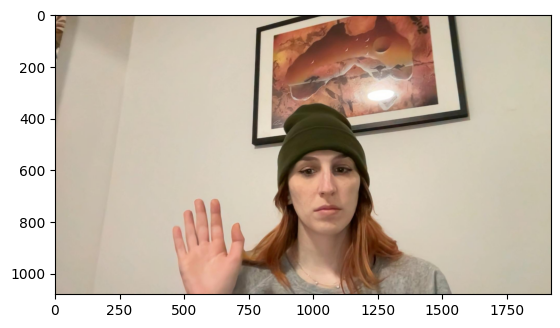

In [66]:
import matplotlib.pyplot as plt

# show one sample (if exists)
sample_imgs = list(train_images.glob("*.*"))
if sample_imgs:
    sample_img = sample_imgs[0]
    sample_label = train_labels / (sample_img.stem + ".txt")
    print("Showing sample:", sample_img.name)
    plt.imshow(plt.imread(sample_img))
else:
    print("No images found in train/images.")

In [67]:
IMG_SIZE = 400

In [68]:
NUMBER_OF_CLASSES = 5

In [111]:
import cv2
import numpy as np

def crop_hand(image_path, model):
    # 1. Przygotuj obraz
    original_img = cv2.imread(image_path)
    img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    input_tensor = np.expand_dims(img_resized, axis=0)

    # 2. Predykcja ramki
    box = model.predict(input_tensor)[0] # [x, y, w, h] (znormalizowane)
    
    # 3. Przelicz na piksele
    h_orig, w_orig, _ = original_img.shape
    x = int(box[0] * w_orig)
    y = int(box[1] * h_orig)
    w = int(box[2] * w_orig)
    h = int(box[3] * h_orig)

    # Zabezpieczenia (żeby nie wyjść poza obraz przy błędzie modelu)
    x = max(0, x)
    y = max(0, y)
    
    # 4. Wycięcie (Crop)
    # Dodajemy mały margines (padding), żeby nie uciąć palców
    padding = 100
    crop = original_img[y-padding : y+h+padding, x-padding : x+w+padding]
    
    return crop, (x, y, w, h)

In [70]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Zakładamy, że detektor był trenowany na 224x224 (zgodnie z naszą poprzednią rozmową)
DETECTOR_SIZE = (IMG_SIZE, IMG_SIZE) 

def load_data_with_detection(img_dir, label_dir, detector_model):
    images = []
    labels = []
    
    img_files = sorted(list(img_dir.glob("*.*")))
    
    print(f"Przetwarzanie {len(img_files)} obrazów z detekcją dłoni...")

    for i, img_path in enumerate(img_files):
        cropped_img, coords = crop_hand(img_path, detector_model)

        # ---------------------------------------------------------
        # ETAP 2: PRZYGOTOWANIE POD KLASYFIKATOR
        # ---------------------------------------------------------
        
        # Resize wycinka do rozmiaru docelowego klasyfikatora (IMG_SIZE)
        hand_crop_resized = cv2.resize(cropped_img, (IMG_SIZE, IMG_SIZE))
        images.append(hand_crop_resized)
        
        # Wczytanie etykiety (bez zmian)
        label_path = label_dir / (img_path.stem + ".txt")
        if label_path.exists():
            with open(label_path, 'r') as f:
                first_line = f.readline().split()
                if first_line:
                    labels.append(int(first_line[0]))
        else:
            labels.append(0)
            
        # Opcjonalnie: Pokaż postęp co 100 zdjęć
        if i % 100 == 0:
            print(f"Przetworzono {i}/{len(img_files)}")

    print("Zakończono wczytywanie.")
    return np.array(images) / 255.0, to_categorical(np.array(labels), num_classes=NUMBER_OF_CLASSES)

In [71]:
X_train, y_train = load_data_with_detection(train_images, train_labels, hand_detector)

Przetwarzanie 298 obrazów z detekcją dłoni...
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Przetworzono 0/298
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [72]:
X_train.shape

(298, 400, 400, 3)

In [73]:
X_test, y_test = load_data_with_detection(test_images, test_labels, hand_detector)

Przetwarzanie 42 obrazów z detekcją dłoni...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Przetworzono 0/42
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

In [74]:
from keras import backend as K

print(K.image_data_format())

channels_last


In [75]:
from keras import layers, models, regularizers

def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x
    
    # --- Główna ścieżka ---
    # 1. Konwolucja
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=False)(x)
    # 2. Batch Norm (KLUCZ DO SUKCESU)
    x = layers.BatchNormalization()(x)
    # 3. Aktywacja
    x = layers.Activation('relu')(x)
    
    # 4. Druga konwolucja
    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    # --- Obsługa skrótu (Shortcut) ---
    # Jeśli zmieniamy wymiary (stride > 1) lub liczbę filtrów, musimy dopasować skrót
    if x.shape[-1] != shortcut.shape[-1] or stride > 1:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
        
    # --- Połączenie ---
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_improved_resnet(img_size, num_classes):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    
    # Wejściowa warstwa - agresywniejsza (stride=2) by zmniejszyć obraz na start
    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    
    # Bloki rezydualne (Coraz więcej filtrów)
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    
    x = residual_block(x, 128, stride=2) # stride=2 zmniejsza obraz o połowę
    x = residual_block(x, 128)
    
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)
    
    # Zakończenie
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x) # Ważne przy małym datasecie!
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model

# Budowa modelu
model = build_improved_resnet(IMG_SIZE, NUMBER_OF_CLASSES)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 400, 400,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 200, 200,  │      9,408 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 200,  │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 200, 200,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 100, 100,  │          0 │ activation_6[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 100, 100,  │     36,864 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 100, 100,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 100, 100,  │     36,864 │ activation_7[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 100, 100,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 100, 100,  │          0 │ add_6[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 100, 100,  │     36,864 │ activation_8[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        256 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 100, 100,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 100, 100,  │     36,864 │ activation_9[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        256 │ conv2d_25[0][0] 

 Total params: 2,854,341 (10.89 MB)

 Trainable params: 2,849,861 (10.87 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [76]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [90]:
# Callbacks - Zatrzymanie treningu, gdy model przestanie się uczyć
callbacks = [
    # tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001),
     # Zapisz model tylko, gdy wynik na walidacji się poprawi
    tf.keras.callbacks.ModelCheckpoint(
        'gesture_classifier.keras', 
        save_best_only=True, 
        monitor='val_loss'
    ),
]

In [91]:
# Start treningu
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.9664 - loss: 0.1141 - val_accuracy: 0.2619 - val_loss: 11.0188 - learning_rate: 3.1250e-05
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9832 - loss: 0.0595 - val_accuracy: 0.2619 - val_loss: 11.7809 - learning_rate: 3.1250e-05
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.9866 - loss: 0.0603 - val_accuracy: 0.2619 - val_loss: 11.8295 - learning_rate: 3.1250e-05
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.9732 - loss: 0.0731 - val_accuracy: 0.2619 - val_loss: 11.5837 - learning_rate: 3.1250e-05
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9799 - loss: 0.0581 - val_accuracy: 0.2619 - val_loss: 11.6632 - learning_rate: 3.1250e-05
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.9966 - loss: 0.0355 - val_accuracy: 0.2619 - val_loss: 11.9660 - learning_rate: 3.1250e-05
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ -1s -111962us/step - acc

In [93]:
score = model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8333 - loss: 0.3309 


In [94]:
from pathlib import Path
import yaml

data_path = root / "data.yaml"

with data_path.open("r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

CLASSES = data["names"]          # list of class names
amount = data.get("nc", len(CLASSES))
print("names:", CLASSES)

names: ['hello', 'iloveyou', 'no', 'thanks', 'yes']


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step 


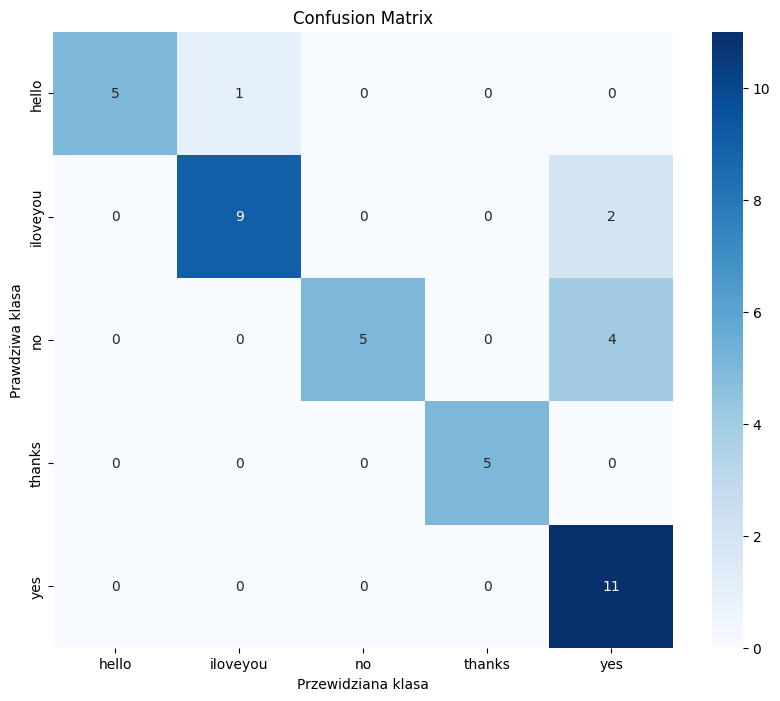

              precision    recall  f1-score   support

       hello       1.00      0.83      0.91         6
    iloveyou       0.90      0.82      0.86        11
          no       1.00      0.56      0.71         9
      thanks       1.00      1.00      1.00         5
         yes       0.65      1.00      0.79        11

    accuracy                           0.83        42
   macro avg       0.91      0.84      0.85        42
weighted avg       0.88      0.83      0.83        42



In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Predykcja na zbiorze testowym
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Macierz pomyłek
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Wykres
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.title('Confusion Matrix')
plt.show()

# 4. Raport tekstowy
print(classification_report(y_true, y_pred_classes, target_names=CLASSES))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predykcja: no z pewnością 99.99%


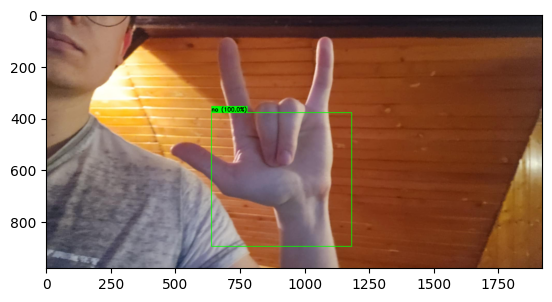

In [112]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def predict_full_pipeline(image_path, detector_model, classifier_model, classes_list):
    img_bgr = cv2.imread(image_path)
    hand_crop, coords = crop_hand(image_path, detector_model)
    x_pad = coords[0]
    y_pad = coords[1]
    w_pad = coords[2]
    h_pad = coords[3]

    # Zabezpieczenie przed pustym wycinkiem (gdyby detektor zawiódł)
    if hand_crop.size == 0:
        print("Nie udało się wyciąć dłoni (błąd detektora).")
        return

    # =========================================================
    # KROK 2: KLASYFIKACJA (Jaki to gest?)
    # =========================================================

    # Preprocessing dla klasyfikatora
    img_cls = cv2.resize(hand_crop, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_cls_batch = np.expand_dims(img_cls, axis=0)

    # Predykcja gestu
    predictions = classifier_model.predict(img_cls_batch, verbose=0)[0]
    class_idx = np.argmax(predictions)       # Indeks najwyższego wyniku
    confidence = predictions[class_idx]      # Pewność (0.0 - 1.0)
    
    predicted_label = classes_list[class_idx]
    
    print(f"Predykcja: {predicted_label} z pewnością {confidence*100:.2f}%")

    # =========================================================
    # KROK 3: WIZUALIZACJA
    # =========================================================
    
    # Kolor ramki zależny od pewności (Zielony = pewny, Żółty = niepewny)
    color = (0, 255, 0) if confidence > 0.7 else (0, 255, 255)

    # Rysujemy ramkę na ORYGINALNYM obrazie BGR
    cv2.rectangle(img_bgr, (x_pad, y_pad), (x_pad + w_pad, y_pad + h_pad), color, 2)

    # Przygotowanie tekstu: "I love You (98%)"
    text = f"{predicted_label} ({confidence*100:.1f}%)"
    
    # Tło pod napisem (dla czytelności)
    (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    cv2.rectangle(img_bgr, (x_pad, y_pad - 25), (x_pad + text_w, y_pad), color, -1)
    
    # Napis
    cv2.putText(img_bgr, text, (x_pad, y_pad - 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    # Pokazanie wyniku
    cropped_img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(cropped_img_rgb)
    # cv2.imshow("Wynik Pipeline", img_bgr)
    
    # Opcjonalnie: Pokaż też, co "widział" klasyfikator (wycinek)
    # cv2.imshow("Co widzi klasyfikator", cv2.cvtColor(hand_crop, cv2.COLOR_RGB2BGR))
    
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# -----------------------------------------------------------
# PRZYKŁAD UŻYCIA
# -----------------------------------------------------------

detector = tf.keras.models.load_model('hand_detector_best.keras')
classifier = tf.keras.models.load_model('gesture_classifier.keras')

# Uruchomienie funkcji
# predict_full_pipeline("Sign Language Detection/babeczka/test/images/thanks_6c96cd1e-7a66-11ed-a1fd-1e08bc6ed8a6_jpg.rf.e5bacbdc5b8d8be361acd4b88a2ecfb9.jpg", detector, classifier, CLASSES)
predict_full_pipeline("./test.jpg", detector, classifier, CLASSES)